In [2]:
import numpy as np
import scipy.interpolate as interp
import starry
import matplotlib.pyplot as plt
from spectres import spectres
import coronagraph as cg

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
/Users/andrew/opt/anaconda3/envs/starry_stable/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
def wav_grid_from_R(R, wav_min, wav_max):
    N = int(np.log(wav_max/wav_min)/np.log(R/(R-1)))
    wav_max = wav_min * (R / (R - 1)) ** (N)
    wav = np.geomspace(wav_min, wav_max, int(N), endpoint = True)
    return wav

def resample_to_R(R, wav, spec, spec_err = None, wav_min = None, wav_max = None, stack = False):
    if wav_min is None:
        wav_min = wav[0]
    if wav_max is None:
        wav_max = wav[-1]

    wav_grid = wav_grid_from_R(R, wav_min, wav_max)

    fill = None
    if wav[0] > wav_grid[0] and wav[-1] < wav_grid[-1]:
        print("Given wavelength range is smaller than interpolated range on both ends. Wav grid will be truncated.")
        wav_grid = wav_grid_from_R(R, wav[0], wav[-1])
    if wav[0] == wav_grid[0]:
        fill = spec[0]
    if wav[-1] == wav_grid[-1]:
        fill = spec[-1]

    if spec_err is not None:
        spec_resamp, spec_err_resamp = spectres(wav_grid, wav, spec, spec_errs = spec_err, fill = fill)
        if stack:
            return np.column_stack((wav_grid, spec_resamp, spec_err_resamp))
        else:
            return wav_grid, spec_resamp
    else:
        spec_resamp = spectres(wav_grid, wav, spec, fill = fill)
        if stack:
            return np.column_stack((wav_grid, spec_resamp))
        else:
            return wav_grid, spec_resamp
        
flux_model = np.loadtxt('/Users/andrew/src/starry/starry/int_flux.txt')

In [80]:
class Telescope:
    def __init__(self, 
                 d_spec_aper = np.array([0.87, 0.71]), 
                 inst_eff = 0.10, 
                 emis_bg = 0.2, 
                 diam = 38.5, 
                 cobs = 0.28, 
                 det_pix_size = np.array([10, 15]), 
                 f_cam = 1.5, 
                 pix_bin_fac = 1, 
                 read_noise = np.array([1, 4.5]),           #e-/pix - different for obs < 0.95 um
                 dar_curr = np.array([1, 20]),              #e-/pix/hr - different for obs < 0.95 um
                 AO = 'No AO'             
                 ):

        self.tel_eff = np.array([[0.36, 0.4, 0.45, 0.55, 0.65, 0.8, 1.25, 1.65, 2.16], [.13, 0.28, 0.44, 0.58, 0.64, 0.68, 0.8, 0.83, 0.84]])     #ESO telescope efficiencies (Table 2 in ANDES ETC)
        self.d_spec_aper = d_spec_aper
        self.inst_eff = inst_eff
        self.emis_bg = emis_bg
        self.diam = diam
        self.cobs = cobs
        self.det_pix_size = det_pix_size
        self.f_cam = f_cam
        self.pix_bin_fac = pix_bin_fac
        self.read_noise = read_noise
        self.dar_curr = dar_curr
        if AO != 'No AO' and AO != 'LTAO' and AO != 'GLAO':
            print("Invalid AO system. Please choose from 'LTAO', 'GLAO', or 'No AO'. Defaulting to 'No AO'.")
            self.AO = 'No AO'
        else:
            self.AO = AO

    def telescope_area(self):
        # In cm^2 
        return np.pi * (self.diam / 2) ** 2 * (1 - self.cobs ** 2) * 10 ** 4

    def pix_theta(self):
        # Sky-projected pixel size in arcsec
        # Will be 2D for lambda <= 0.95 um and lambda > 0.95 um
        return 0.036 * (self.f_cam/1.5) ** (-1) * (self.det_pix_size/10) * (self.diam/38.5) ** (-1)

    def n_pix_spec_aper(self):
        # Number of pixels in the spectrometer aperture
        # Will be 2D for lambda <= 0.95 um and lambda > 0.95 um
        return np.pi / 4. * self.d_spec_aper ** 2 / self.pix_theta() ** 2
    
    def n_readout_pix_per_res(self):
        # Number of readout pixels per resolution element
        # Will be 2D for lambda <= 0.95 um and lambda > 0.95 um
        return int(self.n_pix_spec_aper() / self.pix_bin_fac)

    def telescope_eff(self, wav):
        return np.interp(wav, self.tel_eff[0], self.tel_eff[1])
    
    def slit_eff_interp(self, wav):
        if self.AO == 'No AO':
            eso_table_noAO = np.loadtxt('slit_eff_noAO.txt', skiprows=1)
            func = interp.RectBivariateSpline(x = eso_table_noAO[:,0], y = eso_table_noAO[1:,1], z = eso_table_noAO[:,2:])
        elif self.AO == 'LTAO':
            eso_table_LTAO = np.loadtxt('slit_eff_LTAO.txt', skiprows=1)
            func = interp.RectBivariateSpline(x = eso_table_LTAO[:,0], y = eso_table_LTAO[1:,1], z = eso_table_LTAO[:,2:])
        elif self.AO == 'GLAO':
            eso_table_GLAO = np.loadtxt('slit_eff_GLAO.txt', skiprows=1)
            func = interp.RectBivariateSpline(x = eso_table_GLAO[:,0], y = eso_table_GLAO[1:,1], z = eso_table_GLAO[:,2:])
        return func(self.d_spec_aper, wav)/100.

    def __str__(self):
        return f"Telescope with diameter {self.diameter} and focal length {self.focal_length}"
    
class Observation:
    def __init__(self, Telescope, wav, exp_time, rpow, ndit = 1, airmass = 1., T_bg = 283., mag = None):
        self.telescope = Telescope
        self.mag = mag
        self.wav = wav
        self.exp_time = exp_time        #in seconds
        self.rpow = rpow
        self.sky_bg = np.array([[0.36, 0.44, 0.55, 0.64, 0.8, 1.05, 1.25, 1.65, 2.16], [22.50, 22.50, 21.8, 21.5, 20.5, 20.5, 20., 19.5, 19.5]])
        if exp_time > 30 * 60 * ndit:
            self.ndit = int(np.floor(exp_time / (30 * 60)) + 1)
            print(f"Exposure time exceeds 30 minutes. Number of dithered exposures will be {self.ndit}.")
        else:
            self.ndit = ndit
        self.airmass = airmass
        self.T_bg = T_bg
        self.alpha_atm_trans = np.array([[0.36, 0.44, 0.55, 0.70, 0.90, 1.0, 1.25, 1.65, 2.16, 2.60], [0.67, 0.83, 0.90,0.98, 0.99, 1., 1., 1., 1., 1.]])

    def noise_det(self):
        #Detector noise over detector area corresponding to spectrometer aperture (e-)
        return np.sqrt(self.telescope.n_readout_pix_per_res() * (self.ndit * self.telescope.read_noise ** 2 / self.telescope.pix_bin_fac + self.telescope.dar_curr/3600 * self.exp_time))

    def sky_bg_w_airmass(self):
        #Sky background with airmass correction
        bg = np.interp(self.wav, self.sky_bg[0], self.sky_bg[1])
        return bg - 0.4 * (self.airmass - 1)
    
    def atmospheric_trans(self):
        alpha = np.interp(self.wav, self.alpha_atm_trans[0], self.alpha_atm_trans[1])
        return alpha ** self.airmass
    
    def total_eff(self):
        telescope_eff = self.telescope.telescope_eff(self.wav)
        return telescope_eff * self.telescope.inst_eff * self.atmospheric_trans()
    
    def bg_flux_in_spec_aper(self, print_breakdown = False, plot_breakdown = False):
        #Background flux in spectrometer aperture (e-/s)
        sigma_sky = 10 ** ((16.85 - self.sky_bg_w_airmass()) / 2.5) / self.rpow                                                                 #Sky background in photons/cm^2/s/arcsec^2
        sigma_therm = (1.4 * 10 ** 12 * self.telescope.emis_bg * np.exp(-14388/(self.wav * self.T_bg))) / (self.rpow * self.wav ** 3)           #Thermal background in photons/cm^2/s/arcsec^2
        bg_factor = self.total_eff() * self.telescope.telescope_area() * np.pi / 4. * self.telescope.d_spec_aper ** 2     
        sigma_sky = sigma_sky * bg_factor
        sigma_therm = sigma_therm * bg_factor                      
        if print_breakdown:
            print(f"Sky background: {sigma_sky}")
            print(f"Thermal background: {sigma_therm}")
        if plot_breakdown:
            fig, ax = plt.subplots()
            ax.plot(self.wav, sigma_sky.flatten(), label = "Sky background")
            ax.plot(self.wav, sigma_therm.flatten(), label = "Thermal background")
            ax.legend()
            ax.set_ylabel("Background Flux (e-/s)")
            ax.set_xlabel("Wavelength (um)")
            plt.title("Background Flux Breakdown")
            plt.show()
        return sigma_sky + sigma_therm
    
    def bg_noise(self):
        #Background noise in spectrometer aperture and resolution element (e-)
        return np.sqrt(self.bg_flux_in_spec_aper() * self.exp_time)
    
    def noise_per_res_elem_from_nobj(self):
        #Noise per resolution element (e-)
        return np.sqrt(self.noise_det() ** 2 + self.bg_noise() ** 2 + self.nobj())
    
    def nobj_from_mag(self):
        #Number of object photons per resolution element from target in exposure time (e-)
        return self.telescope.slit_eff_interp(self.wav) * self.total_eff() * self.telescope.telescope_area() * self.exp_time / self.rpow * 10 ** ((16.85 - self.mag) / 2.5)
    
    def nobj(self):
        #Number of object photons per resolution element from target in exposure time (e-)
        num_hours = self.exp_time / 3600.
        N = num_hours * flux_model / 100 ** 2
        return self.telescope.slit_eff_interp(self.wav) * self.total_eff() * self.telescope.telescope_area() /self.rpow * N
    
    def snr(self, print_breakdown = False, plot_breakdown = False):
        #Signal-to-noise ratio per resolution element
        snr = np.sqrt(self.nobj() / self.noise_per_res_elem_from_nobj())
        return snr

    def snr_from_mag(self, print_breakdown = False, plot_breakdown = False):
        #Signal-to-noise ratio per resolution element from target in exposure time
        term = self.telescope.slit_eff_interp(self.wav) * self.total_eff() * self.telescope.telescope_area() * self.exp_time / self.rpow * 10 ** ((16.85 - self.mag) / 2.5)
        snr = np.sqrt(term ** 2 / (self.noise_det() ** 2 + self.bg_noise() ** 2 + term))
        if print_breakdown:
            print(f"SNR: {snr}")
            print(f"Object photon noise: {100 * term/(self.noise_det() ** 2 + self.bg_noise() ** 2 + term)}%")
            print(f"Detector noise: {100 * self.noise_det() ** 2/(self.noise_det() ** 2 + self.bg_noise() ** 2 + term)}%")
            print(f"Background noise: {100 * self.bg_noise() ** 2/(self.noise_det() ** 2 + self.bg_noise() ** 2 + term)}%")
        if plot_breakdown:
            fig, ax = plt.subplots()
            ax.plot(self.wav, snr.flatten(), label = "SNR per resolution element")
            ax2 = ax.twinx()
            ax2.plot(self.wav, (100 * term/(self.noise_det() ** 2 + self.bg_noise() ** 2 + term)).flatten(), label = "% Object photon noise")
            ax2.plot(self.wav, (100 * self.noise_det() ** 2/(self.noise_det() ** 2 + self.bg_noise() ** 2 + term)).flatten(), label = "% Detector noise")
            ax2.plot(self.wav, (100 * self.bg_noise() ** 2/(self.noise_det() ** 2 + self.bg_noise() ** 2 + term)).flatten(), label = "% Background noise")
            ax.legend()
            ax2.legend()
            ax.set_ylabel("SNR")
            ax2.set_ylabel("% Contribution to Noise")
            ax.set_xlabel("Wavelength (um)")
            plt.title("SNR and Noise Breakdown")
            plt.show()
        return snr

    def __str__(self):
        return f"Observation with telescope {self.telescope} and wavelength {self.wav}"

In [73]:
wav = np.linspace(0.4, 2.5, 100)

elt_short = Telescope(d_spec_aper=0.87, det_pix_size=10, read_noise=1, dar_curr=1., AO='LTAO')
elt_long = Telescope(d_spec_aper=0.71, det_pix_size=15, read_noise=4.5, dar_curr=20., AO='LTAO')
obs_short = Observation(elt_short, wav, exp_time = 1800, rpow = 100, mag = 16.57)
obs_long = Observation(elt_long, wav, exp_time = 1800, rpow = 100, mag = 16.57)


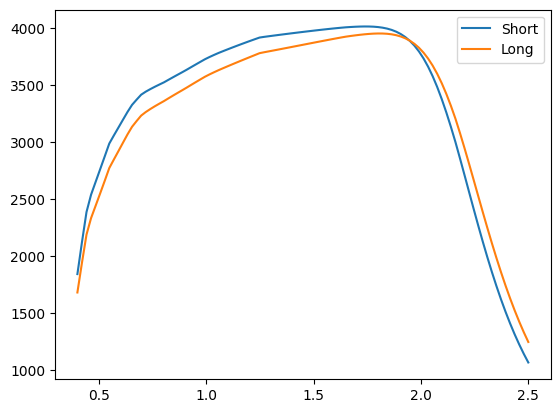

In [66]:
plt.plot(wav, obs_short.snr_from_mag().flatten(), label = "Short") 
plt.plot(wav, obs_long.snr_from_mag().flatten(), label = "Long")
plt.legend()
plt.show()

In [69]:
proxb_wav, proxb_mag = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/proximab/proxb_mag_albedo2E-7_from_starry_mod.txt', unpack = True)

proxb_wav, proxb_mag = resample_to_R(100, proxb_wav, proxb_mag, wav_min = 0.41, wav_max = 2.4)

In [67]:
obs_proxb = Observation(elt_short, wav = proxb_wav, exp_time =  60, rpow = 100, mag = proxb_mag)
3600* 8

print(proxb_wav.shape)
print(proxb_mag.shape)


(175,)
(175,)


Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.


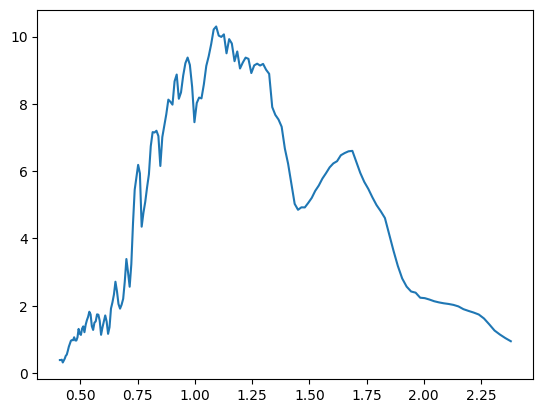

In [83]:
obs_from_photons = Observation(elt_short, wav = proxb_wav, exp_time = 8*60*60, rpow = 100)
snr = obs_from_photons.snr()

plt.plot(proxb_wav, snr.flatten())
plt.show()

np.savetxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/proximab/proxb_snr_R100.txt', np.column_stack((proxb_wav, snr.flatten())), header = "Wavelength (um) SNR")

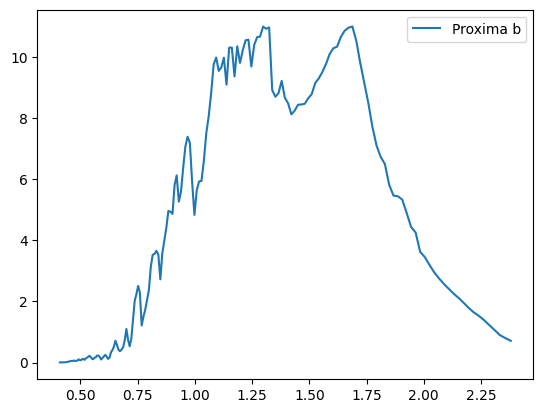

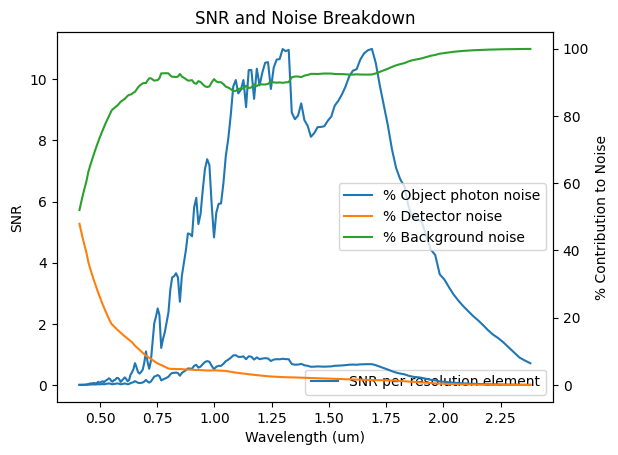

In [13]:
plt.plot(proxb_wav, obs_proxb.snr_from_mag().flatten(), label = "Proxima b")
plt.legend()
plt.show()

obs_proxb.snr_from_mag(plot_breakdown = True)

np.savetxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/proximab/proxb_snr_R100.txt', np.column_stack((proxb_wav, obs_proxb.snr_from_mag().flatten())), header = "Wavelength (um) SNR")

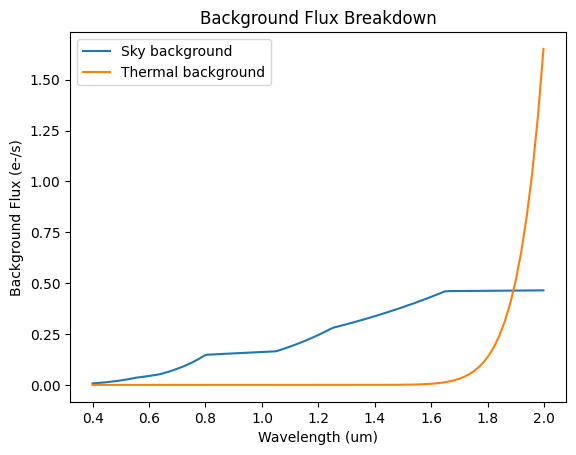

array([0.0073604 , 0.00778594, 0.00822333, 0.00867285, 0.00913478,
       0.00960941, 0.01009703, 0.01059794, 0.01111244, 0.01164085,
       0.01231652, 0.01312799, 0.0138947 , 0.01453156, 0.01520119,
       0.01590548, 0.01664643, 0.01742621, 0.0182471 , 0.01911152,
       0.02002208, 0.02098154, 0.02199284, 0.02305914, 0.02418378,
       0.02537035, 0.02662268, 0.02794484, 0.02934121, 0.03081644,
       0.03237554, 0.03402384, 0.0353327 , 0.03627616, 0.03725311,
       0.03826498, 0.03931324, 0.04039945, 0.04152524, 0.04269231,
       0.04390247, 0.04515758, 0.04645964, 0.04781072, 0.04921299,
       0.05066875, 0.0521804 , 0.05424691, 0.05688385, 0.05947173,
       0.06220291, 0.0650878 , 0.06813639, 0.07135937, 0.07476823,
       0.07837531, 0.08200237, 0.08573526, 0.08967786, 0.09384381,
       0.09824775, 0.10290537, 0.10783356, 0.11305045, 0.11857553,
       0.12442977, 0.13063574, 0.13721775, 0.14420197, 0.14837129,
       0.14890769, 0.14944993, 0.1499981 , 0.15055225, 0.15111

In [28]:
obs_proxb.bg_flux_in_spec_aper(plot_breakdown = True)

In [7]:
wav = np.linspace(0.36, 2.16, 100)
wav = np.array([wav[wav <= 0.95], wav[wav > 0.95]], dtype=object)
print(wav[0].shape)
print(wav[1].shape)


(33,)
(67,)


In [8]:
class LittleTeapot:
    def __init__(self, short = True, stout = True, handle_loc = 'here', spout_loc = 'there', steamed_up = False, tipped = False, full = True):
        self.short = short
        self.stout = stout
        self.handle_loc = handle_loc
        self.spout_loc = spout_loc
        self.steamed_up = steamed_up
        self.tipped = tipped
        self.full = full
    
    def steam_me_up(self):
        if not self.steamed_up:
            self.steamed_up = True
        print("Hear me shout!")
        self.pour_me_out()
        return None
    
    def pour_me_out(self):
        self.tipped = True
        self.steamed_up = False
        self.full = False
        return None
    
    def reset(self):
        self.steamed_up = False
        self.full = True
        self.tipped = False
        return None
    
me = LittleTeapot()

me.handle_loc
me.spout_loc

me.steam_me_up()


Hear me shout!


In [27]:
###No AO Table (Table 4) from https://www.eso.org/observing/etc/doc/elt/etc_spec_model.pdf
###DAPE values correspond to R_ref values of 2.2, 10.0, 50.0, 100.0, 200.0, 300.0, 400.0, 500.0, 800.0

dape = np.array([0.0044, 0.0200, 0.1, 0.2, 0.4, 0.6, 0.8, 1., 1.6])
U = np.array([0.00229, 0.0478, 1.19, 4.66, 17.1, 33.5, 50., 64., 88.])
B = np.array([0.00263, 0.0523, 1.3, 5.08, 18.4, 35.6, 52.4, 66.1, 88.3])
V = np.array([0.00282, 0.0584, 1.46, 5.68, 20.37, 38.5, 55.5, 68.8, 88.9])
R = np.array([0.00325, 0.0685, 1.67, 6.47, 22.7, 42., 59.1, 71.8, 89.8])
I = np.array([0.0038, 0.0792, 1.94, 7.46, 25.6, 46.1, 63., 74.8, 90.7])
J = np.array([0.0048, 0.0968, 2.42, 9.13, 30.1, 51.8, 68., 78.5, 91.8])
H = np.array([0.00474, 0.116, 2.93, 11., 34.7, 56.8, 71.9, 81.2, 92.6])
K = np.array([0.00646, 0.153, 3.76, 13.7, 40.1, 61.9, 75.6, 83.6, 93.3])
wav = np.array([0, 0.36, 0.44, 0.55, 0.64, 0.8, 1.25, 1.65, 2.16])

np.savetxt('slit_eff_noAO.txt', np.array([dape, wav, U, B, V, R, I, J, H, K]).T, delimiter = ' ', fmt = '%.5f', header = 'dape wav U B V R I J H K')

In [137]:
###GLAO table (Table 5) from https://www.eso.org/observing/etc/doc/elt/etc_spec_model.pdf

dape = np.array([0.0044, 0.0200, 0.1, 0.2, 0.4, 0.6, 0.8, 1., 1.6])
U = np.array([0.00278, 0.0577, 1.43, 5.55, 19.8, 37.7, 54.5, 67.9, 89.3])
B = np.array([0.00319, 0.0642, 1.6, 6.19, 21.8, 40.5, 57.2, 70., 89.4])
V = np.array([0.00376, 0.0758, 1.87, 7.16, 24.6, 44.2, 60.7, 72.7, 89.9])
R = np.array([0.00446, 0.0928, 2.26, 8.54, 28.2, 48.7, 64.7, 75.6, 90.6])
I = np.array([0.00594, 0.119, 2.84, 10.5, 32.8, 53.7, 68.7, 78.4, 91.4])
J = np.array([0.00957, 0.179, 4.09, 14.4, 40.2, 60.5, 73.6, 81.7, 92.3])
H = np.array([0.0136, 0.28, 5.94, 19.5, 47.4, 66., 77.2, 84.1, 93.1])
K = np.array([0.031, 0.539, 9.41, 26.7, 55.1, 71.2, 80.5, 86.1, 93.7])
wav = np.array([0, 0.36, 0.44, 0.55, 0.64, 0.8, 1.25, 1.65, 2.16])

np.savetxt('slit_eff_GLAO.txt', np.array([dape, wav, U, B, V, R, I, J, H, K]).T, delimiter = ' ', fmt = '%.5f', header = 'dape wav U B V R I J H K')

###LTAO table (Table 6) from https://www.eso.org/observing/etc/doc/elt/etc_spec_model.pdf

dape = np.array([0.0044, 0.0200, 0.1, 0.2, 0.4, 0.6, 0.8, 1., 1.6])
U = np.array([0.004, 0.079, 1.91, 7.27, 24.3, 43.2, 59.1, 70.9, 89.3])
B = np.array([0.005, 0.104, 2.35, 8.67, 27.5, 46.7, 61.9, 72.8, 89.2])
V = np.array([0.016, 0.196, 3.35, 11.2, 32.1, 51.2, 65.4, 75.1, 89.4])
R = np.array([0.161, 0.794, 5.78, 15.8, 38.1, 56.4, 69.1, 77.6, 89.8])
I = np.array([0.973, 3.8, 10.9, 23.2, 44.9, 61.6, 72.7, 80., 90.4])
J = np.array([3.08, 13.6, 23.8, 36.2, 55.1, 67.6, 76.8, 82.7, 91.2])
H = np.array([4.39, 24.2, 39.4, 48.2, 63.8, 73.1, 79.4, 84.6, 91.9])
K = np.array([4.49, 35.5, 55., 60.6, 71.6, 78.5, 83., 86.2, 92.5])

np.savetxt('slit_eff_LTAO.txt', np.array([dape, wav, U, B, V, R, I, J, H, K]).T, delimiter = ' ', fmt = '%.5f', header = 'dape wav U B V R I J H K')